In [38]:
import pandas as pd

df = pd.read_csv("../data/raw_metadata.csv")

df.head()

,video_id,title,publish_date
0,0XMdbWy2j1w,Can you guess what this is? Wrong answers only!,2026-03-09T12:17:22Z
1,ldkfMvE36FI,How to handle being thrown into an existing co...,2026-03-08T12:43:26Z
2,jie_039IekA,Why you shouldn't chase people to get what you...,2026-03-07T13:32:30Z
3,mrRfPVm9nAY,Learn the basics of Data Structures in 60 seco...,2026-03-06T13:18:50Z
4,hP931079TMw,There are 2 kinds of devs. One of them is scre...,2026-03-06T11:01:15Z


In [39]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw_metadata.csv")

# Display first 5 rows
df.head()

# Print dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (250, 3)


In [40]:
# Check column names
print("Column Names:")
print(df.columns)

# Check data types and non-null values
print("\nDataset Info:")
df.info()

# Total number of rows
print("\nTotal Rows:", len(df))

# Confirm required columns exist
required_columns = ["video_id", "title", "publish_date"]

print("\nRequired Columns Check:")
for col in required_columns:
    if col in df.columns:
        print(f"✔ {col} exists")
    else:
        print(f"✘ {col} is missing")

Column Names:
Index(['video_id', 'title', 'publish_date'], dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   video_id      250 non-null    str  
 1   title         250 non-null    str  
 2   publish_date  250 non-null    str  
dtypes: str(3)
memory usage: 6.0 KB

Total Rows: 250

Required Columns Check:
✔ video_id exists
✔ title exists
✔ publish_date exists


In [41]:
# Check duplicate video_id
print("Duplicate video_id count:", df["video_id"].duplicated().sum())

# Check duplicate titles
print("Duplicate title count:", df["title"].duplicated().sum())

# Show duplicate rows (optional)
print("\nDuplicate video_id rows:")
print(df[df["video_id"].duplicated()])

# Remove duplicate video_id entries (keep first occurrence)
df = df.drop_duplicates(subset="video_id", keep="first")

# Verify duplicates removed
print("\nDuplicate video_id after cleaning:", df["video_id"].duplicated().sum())

Duplicate video_id count: 0
Duplicate title count: 0

Duplicate video_id rows:
Empty DataFrame
Columns: [video_id, title, publish_date]
Index: []

Duplicate video_id after cleaning: 0


In [42]:
# Check missing values in specific columns
print("Missing video_id:", df["video_id"].isnull().sum())
print("Missing title:", df["title"].isnull().sum())
print("Missing publish_date:", df["publish_date"].isnull().sum())

# Display rows with missing values (optional inspection)
print("\nRows with missing values:")
print(df[df[["video_id", "title", "publish_date"]].isnull().any(axis=1)])

# If missing values exist → remove those rows
df = df.dropna(subset=["video_id", "title", "publish_date"])

# Verify after cleaning
print("\nMissing values after cleaning:")
print(df[["video_id", "title", "publish_date"]].isnull().sum())

Missing video_id: 0
Missing title: 0
Missing publish_date: 0

Rows with missing values:
Empty DataFrame
Columns: [video_id, title, publish_date]
Index: []

Missing values after cleaning:
video_id        0
title           0
publish_date    0
dtype: int64


In [43]:
# Convert publish_date to datetime format
df["publish_date"] = pd.to_datetime(df["publish_date"])

# Extract year
df["year"] = df["publish_date"].dt.year

# Extract month
df["month"] = df["publish_date"].dt.month

# Check result
df.head()

,video_id,title,publish_date,year,month
0,0XMdbWy2j1w,Can you guess what this is? Wrong answers only!,2026-03-09 12:17:22+00:00,2026,3
1,ldkfMvE36FI,How to handle being thrown into an existing co...,2026-03-08 12:43:26+00:00,2026,3
2,jie_039IekA,Why you shouldn't chase people to get what you...,2026-03-07 13:32:30+00:00,2026,3
3,mrRfPVm9nAY,Learn the basics of Data Structures in 60 seco...,2026-03-06 13:18:50+00:00,2026,3
4,hP931079TMw,There are 2 kinds of devs. One of them is scre...,2026-03-06 11:01:15+00:00,2026,3


In [11]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


Videos per Year:
year
2025    149
2026    101
Name: count, dtype: int64

Videos per Month:
month
1     45
2     43
3     13
8      5
9     18
10    37
11    45
12    44
Name: count, dtype: int64


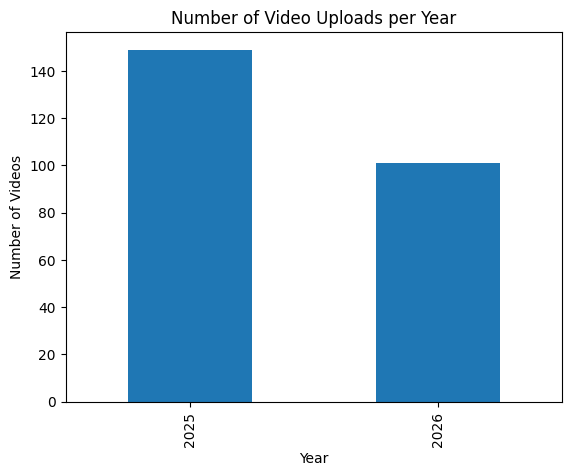

In [44]:
# Count number of videos per year
videos_per_year = df["year"].value_counts().sort_index()

print("Videos per Year:")
print(videos_per_year)

# Count number of videos per month
videos_per_month = df["month"].value_counts().sort_index()

print("\nVideos per Month:")
print(videos_per_month)

# Bar chart: uploads per year
import matplotlib.pyplot as plt

videos_per_year.plot(kind="bar")

plt.title("Number of Video Uploads per Year")
plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.show()

Shortest Title:
Code a turkey timer! | Length: 20

Longest Title:
When NOT to use AI in your hackathon project with MLH winners Cindy Cui and Alison Co [Podcast #198] | Length: 100

Average Title Length: 65.224


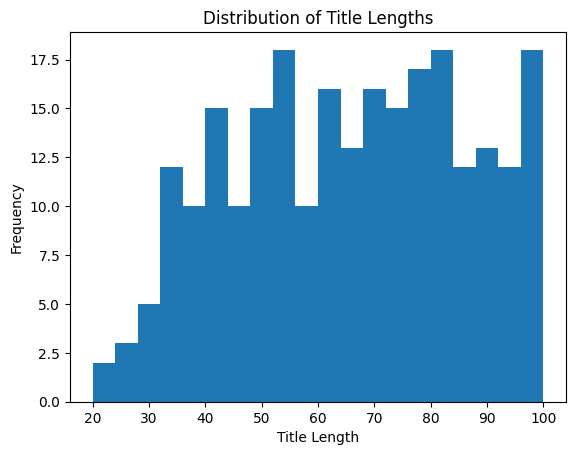

In [45]:
# Calculate title length (number of characters)
df["title_length"] = df["title"].str.len()

# Find shortest title
shortest_title = df.loc[df["title_length"].idxmin()]
print("Shortest Title:")
print(shortest_title["title"], "| Length:", shortest_title["title_length"])

# Find longest title
longest_title = df.loc[df["title_length"].idxmax()]
print("\nLongest Title:")
print(longest_title["title"], "| Length:", longest_title["title_length"])

# Compute average title length
avg_length = df["title_length"].mean()
print("\nAverage Title Length:", avg_length)

# Plot distribution of title lengths
import matplotlib.pyplot as plt

df["title_length"].plot(kind="hist", bins=20)

plt.title("Distribution of Title Lengths")
plt.xlabel("Title Length")
plt.ylabel("Frequency")
plt.show()

In [46]:
# Total number of unique videos
total_unique_videos = df["video_id"].nunique()
print("Total Unique Videos:", total_unique_videos)

# Check if dataset falls within 100–350 range
if 100 <= total_unique_videos <= 350:
    print("Dataset size is within the required 100–350 range.")
elif total_unique_videos < 100:
    print("Dataset is smaller than the required range (too small).")
else:
    print("Dataset exceeds the required range (too large).")

# Date range covered by videos
min_date = df["publish_date"].min()
max_date = df["publish_date"].max()

print("\nDate Range Covered:")
print("From:", min_date)
print("To:", max_date)

# Basic repetition check (duplicate titles percentage)
duplicate_titles = df["title"].duplicated().sum()
print("\nDuplicate Titles Count:", duplicate_titles)

# Simple diversity check (unique titles ratio)
unique_titles_ratio = df["title"].nunique() / len(df)
print("Unique Title Ratio:", round(unique_titles_ratio, 2))

Total Unique Videos: 250
Dataset size is within the required 100–350 range.

Date Range Covered:
From: 2025-08-22 13:15:07+00:00
To: 2026-03-09 12:17:22+00:00

Duplicate Titles Count: 0
Unique Title Ratio: 1.0


In [47]:
# Remove extra spaces (leading and trailing)
df["title"] = df["title"].str.strip()

# Remove newline characters
df["title"] = df["title"].str.replace("\n", " ", regex=False)

# Standardize formatting (optional: normalize multiple spaces to single space)
df["title"] = df["title"].str.replace(r"\s+", " ", regex=True)

# Preview cleaned titles
df.head()

,video_id,title,publish_date,year,month,title_length
0,0XMdbWy2j1w,Can you guess what this is? Wrong answers only!,2026-03-09 12:17:22+00:00,2026,3,47
1,ldkfMvE36FI,How to handle being thrown into an existing co...,2026-03-08 12:43:26+00:00,2026,3,88
2,jie_039IekA,Why you shouldn't chase people to get what you...,2026-03-07 13:32:30+00:00,2026,3,83
3,mrRfPVm9nAY,Learn the basics of Data Structures in 60 seco...,2026-03-06 13:18:50+00:00,2026,3,67
4,hP931079TMw,There are 2 kinds of devs. One of them is scre...,2026-03-06 11:01:15+00:00,2026,3,89


In [48]:
import re

# Remove emojis using regex
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # symbols & pictographs
    u"\U0001F680-\U0001F6FF"  # transport & map symbols
    u"\U0001F700-\U0001F77F"
    u"\U0001F780-\U0001F7FF"
    u"\U0001F800-\U0001F8FF"
    u"\U0001F900-\U0001F9FF"
    u"\U0001FA00-\U0001FA6F"
    u"\U0001FA70-\U0001FAFF"
    u"\U00002700-\U000027BF"
    u"\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

df["title"] = df["title"].apply(lambda x: emoji_pattern.sub(r'', x))

In [49]:
# Ensure no duplicate video_id entries
df = df.drop_duplicates(subset="video_id", keep="first")

# Ensure no null video_id values
df = df.dropna(subset=["video_id"])

# Ensure publish_date is proper datetime format
df["publish_date"] = pd.to_datetime(df["publish_date"], errors="coerce")

# Optional: remove rows where datetime conversion failed
df = df.dropna(subset=["publish_date"])

# Save cleaned dataset to CSV
df.to_csv("cleaned_metadata.csv", index=False)

print("Cleaned dataset saved successfully ")

Cleaned dataset saved successfully 
